# PM Accelerator Weather Forecasting Project

# Notebook 03 — Exploratory Data Analysis

---

## Objective

The purpose of this notebook is to explore the Global Weather Repository
dataset, understand the distributions and relationships of weather
variables, identify patterns, and generate insights that will guide
feature engineering and forecasting model development.

Unlike Notebook 02, which focused on data quality, this notebook focuses
on understanding the data itself.

---

## Inputs

- Preprocessed weather dataset
- Analysis package
- Visualization package

---

## Outputs

- Publication-quality visualizations
- Statistical summaries
- Correlation analysis
- Geographic analysis
- Forecasting target selection
- Modeling recommendations

---

## Expected Deliverables

By the end of this notebook we will:

- Understand all major weather variables
- Identify important feature relationships
- Select the forecasting target
- Select the forecasting location
- Produce publication-quality figures
- Generate recommendations for feature engineering

# Workflow

1. Configure notebook environment
2. Import project modules
3. Load dataset
4. Validate dataset
5. Analyze numerical variables
6. Analyze categorical variables
7. Perform correlation analysis
8. Perform geographic analysis
9. Analyze temporal variables
10. Select forecasting target
11. Summarize findings

# Imports

## Purpose

Import all required project modules, reusable analysis utilities,
visualization functions, and third-party libraries used throughout
this notebook.

All reusable functionality should be imported from the `src`
package. No analytical logic should be implemented in this section.

In [123]:
# ---------------------------------------------------------------------
# Project Root
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---------------------------------------------------------------------
# Standard Library Imports
# ---------------------------------------------------------------------

import warnings

# ---------------------------------------------------------------------
# Third-Party Imports
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------------------
# Project Modules
# ---------------------------------------------------------------------

from src.data_loader import load_weather_dataset
from src.preprocessing import preprocess_dataset

# Analysis
from src.analysis.summary import dataset_summary
from src.analysis.numerical import numerical_summary
from src.analysis.categorical import top_categories
from src.analysis.diagnostics import (
    duplicate_rows,
    missing_values,
)

# Visualization
from src.visualization.distributions import (
    plot_histogram,
    plot_boxplot,
)

from src.visualization.categorical import (
    plot_bar_chart,
)

from src.visualization.correlation import (
    plot_correlation_heatmap,
    get_high_correlations,
)
from src.visualization.scatter import (
    plot_scatter,
)
from src.visualization.geographic import (
    plot_scatter_map,
)


# Notebook Configuration

## Purpose

Configure notebook display settings to improve readability of
tables, figures, and statistical summaries throughout the
exploratory analysis.

These settings ensure that large tables and long feature names
are displayed consistently.

In [124]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (12, 6)

# Load Dataset

## Purpose

Load the Global Weather Repository dataset and execute the
standardized preprocessing pipeline.

The resulting DataFrame will be used throughout the remainder
of this notebook.

In [125]:
df = load_weather_dataset()

df = preprocess_dataset(df)

2026-07-08 17:35:16 | INFO | src.data_loader | Loading weather dataset...
2026-07-08 17:35:17 | INFO | src.data_loader | Dataset loaded successfully (151827 rows, 41 columns).
2026-07-08 17:35:17 | INFO | src.preprocessing | ============================================================
2026-07-08 17:35:17 | INFO | src.preprocessing | Starting preprocessing pipeline...
2026-07-08 17:35:17 | INFO | src.preprocessing | ============================================================
2026-07-08 17:35:17 | INFO | src.preprocessing | Converting last_updated to datetime...
2026-07-08 17:35:17 | INFO | src.preprocessing | 0 duplicate rows removed.
2026-07-08 17:35:17 | INFO | src.preprocessing | Sorting dataset by last_updated...
2026-07-08 17:35:17 | INFO | src.preprocessing | Preprocessing complete.


# Dataset Verification

## Purpose

Perform a brief verification to confirm that the dataset has
been loaded correctly and is ready for exploratory analysis.

A complete validation was performed in Notebook 02. Here we
only confirm that no unexpected issues have been introduced.

In [126]:
dataset_summary(df)

,Metric,Value
0,Rows,151827.00
1,Columns,41.00
2,Missing Values,0.00
3,Duplicate Rows,0.00
4,Memory Usage (MB),119.76


In [127]:
print(
    f"Duplicate Rows: {duplicate_rows(df)}"
)

Duplicate Rows: 0


In [128]:
missing_values(df).head()

country                  0
feels_like_fahrenheit    0
visibility_miles         0
uv_index                 0
gust_mph                 0
dtype: int64

## Verification Summary

The dataset was successfully loaded and preprocessed using the
standardized project pipeline.

A brief verification confirms that the dataset remains suitable
for exploratory analysis. No duplicate records or missing values
were identified, and the dataset is ready for deeper statistical
investigation.

# 1. Temperature Analysis

## Objective

Temperature is one of the most important weather variables and serves as a
primary indicator of atmospheric conditions. Since future phases of this
project will focus on forecasting weather behavior, understanding the
distribution and variability of temperature is an essential first step.

This analysis examines the statistical distribution, identifies potential
outliers, and evaluates whether the data appears suitable for predictive
modeling.

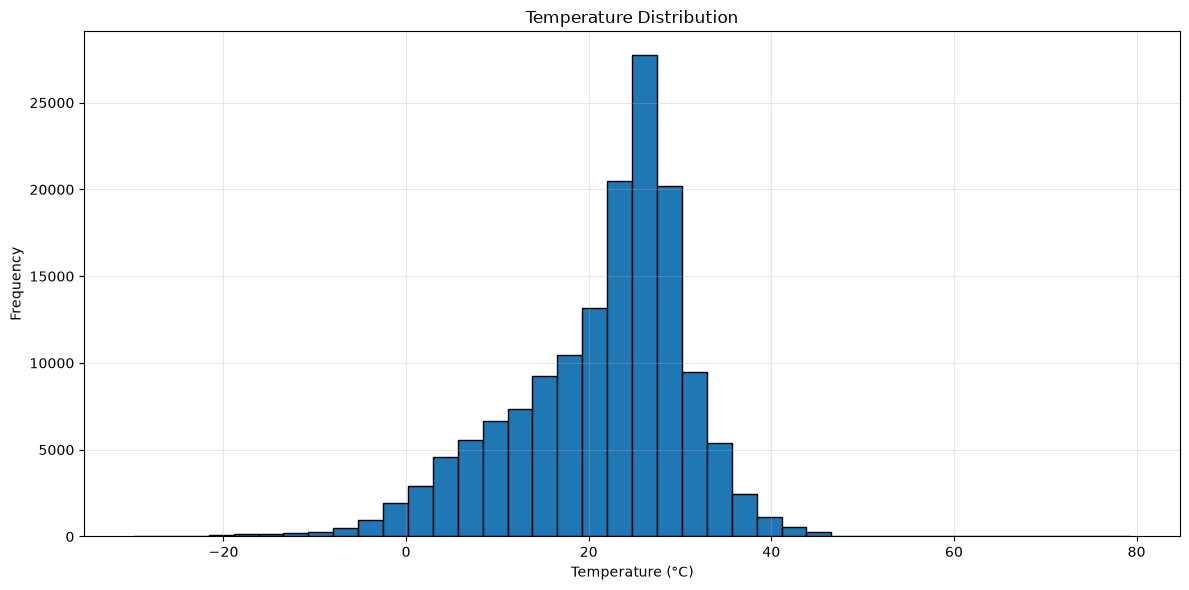

In [129]:
plot_histogram(
    df=df,
    column="temperature_celsius",
    title="Temperature Distribution",
    xlabel="Temperature (°C)",
    filename="temperature_histogram.png",
)

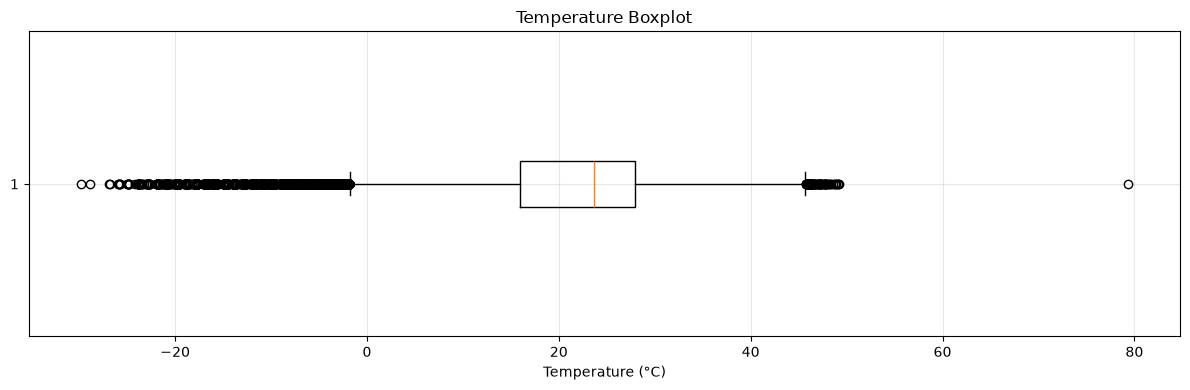

In [130]:
plot_boxplot(
    df=df,
    column="temperature_celsius",
    title="Temperature Boxplot",
    xlabel="Temperature (°C)",
    filename="temperature_boxplot.png",
)

In [131]:
numerical_summary(
    df,
    "temperature_celsius",
)

count    151827.000000
mean         21.338242
std           9.507643
min         -29.800000
25%          16.000000
50%          23.700000
75%          27.900000
max          79.300000
Name: temperature_celsius, dtype: float64

In [132]:
temp = df["temperature_celsius"]

print(f"Mean: {temp.mean():.2f} °C")
print(f"Median: {temp.median():.2f} °C")
print(f"Standard Deviation: {temp.std():.2f}")
print(f"Minimum: {temp.min():.2f} °C")
print(f"Maximum: {temp.max():.2f} °C")
print(f"Skewness: {temp.skew():.2f}")
print(f"Kurtosis: {temp.kurtosis():.2f}")

Mean: 21.34 °C
Median: 23.70 °C
Standard Deviation: 9.51
Minimum: -29.80 °C
Maximum: 79.30 °C
Skewness: -0.83
Kurtosis: 0.81


### Interpretation

#### Distribution

The temperature distribution is unimodal, with the highest concentration of observations between approximately 15°C and 30°C. The distribution exhibits a slight negative (left) skew, as indicated by the skewness value of -0.83 and the fact that the median temperature (23.7°C) is greater than the mean (21.34°C). This suggests that while most observations represent moderate temperatures, a smaller number of unusually cold observations extend the lower tail of the distribution.

#### Outliers

The boxplot reveals several outliers on both the lower and upper ends of the distribution. Temperatures below 0°C and above approximately 45°C occur relatively infrequently but represent legitimate extreme weather conditions rather than obvious data quality issues. The maximum recorded temperature of 79.3°C is exceptionally high and should be investigated further during later quality assurance and feature engineering stages.

#### Statistical Characteristics

The dataset contains 151,827 observations with temperatures ranging from -29.8°C to 79.3°C. The standard deviation of 9.51°C indicates moderate variability across locations and observation times. Overall, the distribution appears sufficiently well-behaved for exploratory analysis while preserving naturally occurring environmental extremes.

#### Modeling Implications

Temperature demonstrates substantial variation across the global dataset, making it an informative target for predictive modeling. Although several extreme observations exist, they appear to represent genuine weather events rather than missing or corrupted data. Robust machine learning models should be able to accommodate these values without requiring aggressive outlier removal.

### Key Insights

- The dataset contains over 151,000 temperature observations spanning a wide range of global climates.
- Most observations fall between approximately 15°C and 30°C, indicating that moderate temperatures dominate the dataset.
- The distribution is slightly left-skewed, reflecting a relatively small number of unusually cold observations.
- Extreme temperatures exist but appear to be plausible environmental measurements rather than obvious data errors.
- The observed variability suggests that temperature is a strong candidate for forecasting and predictive modeling.

# 2. Humidity Analysis

## Objective

Humidity influences atmospheric conditions, precipitation, and perceived temperature. Understanding its distribution provides insight into moisture variability across geographic regions and helps identify whether humidity should be transformed or engineered as a predictive feature during model development.

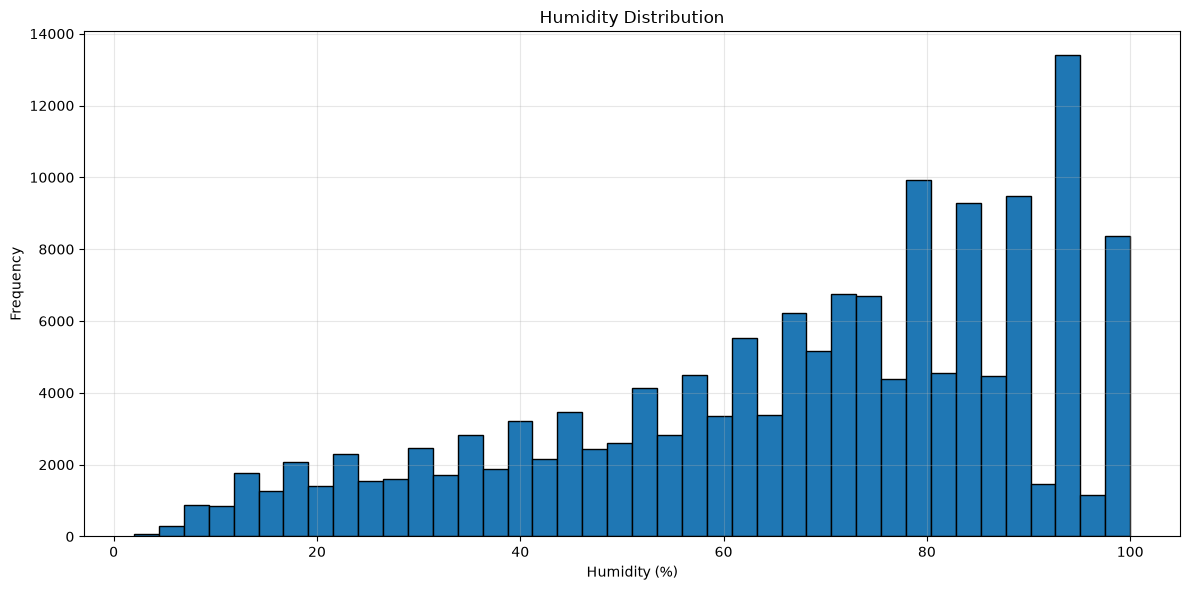

In [133]:
plot_histogram(
    df=df,
    column="humidity",
    title="Humidity Distribution",
    xlabel="Humidity (%)",
    filename="humidity_distribution.png",
)

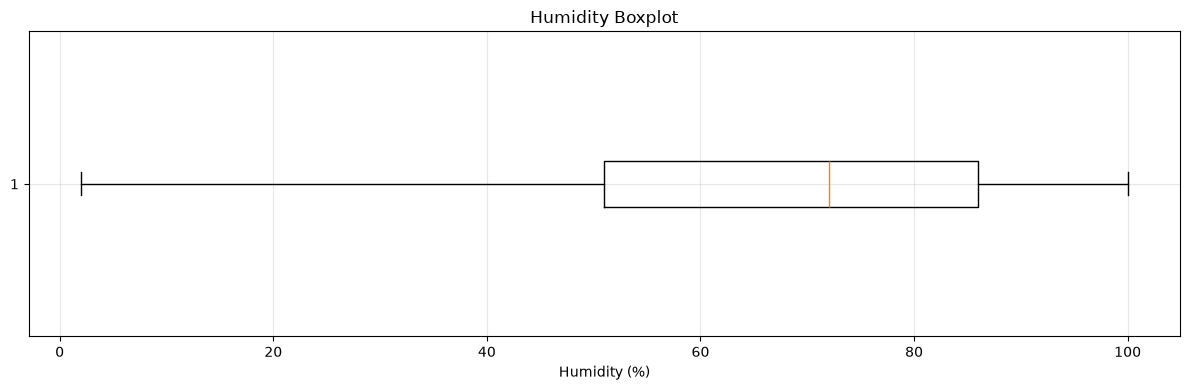

In [134]:
plot_boxplot(
    df=df,
    column="humidity",
    title="Humidity Boxplot",
    xlabel="Humidity (%)",
    filename="humidity_boxplot.png",
)

In [135]:
numerical_summary(
    df,
    "humidity",
)

count    151827.000000
mean         66.925586
std          23.654361
min           2.000000
25%          51.000000
50%          72.000000
75%          86.000000
max         100.000000
Name: humidity, dtype: float64

In [136]:
humidity = df["humidity"]

print(f"Mean: {humidity.mean():.2f}%")
print(f"Median: {humidity.median():.2f}%")
print(f"Standard Deviation: {humidity.std():.2f}")
print(f"Minimum: {humidity.min():.2f}%")
print(f"Maximum: {humidity.max():.2f}%")
print(f"Skewness: {humidity.skew():.2f}")
print(f"Kurtosis: {humidity.kurtosis():.2f}")

Mean: 66.93%
Median: 72.00%
Standard Deviation: 23.65
Minimum: 2.00%
Maximum: 100.00%
Skewness: -0.67
Kurtosis: -0.46


### Interpretation

#### Distribution

The humidity distribution is concentrated toward higher values, with the majority of observations falling between approximately 50% and 100%. Statistical measures indicate a slight negative (left) skew, as evidenced by the skewness value of -0.67 and the median humidity (72%) exceeding the mean (66.93%). This suggests that while high humidity conditions are common, a smaller number of unusually dry observations extend the lower tail of the distribution.

#### Outliers

The boxplot shows no significant outliers, indicating that humidity values are naturally bounded within the expected physical range of 0% to 100%. The absence of extreme observations suggests consistent data quality and reduces the need for outlier treatment during preprocessing.

#### Statistical Characteristics

The dataset contains 151,827 humidity observations ranging from 2% to 100%, with a standard deviation of 23.65%. This relatively large spread reflects substantial variation in atmospheric moisture across different geographic locations and environmental conditions.

#### Modeling Implications

Humidity demonstrates considerable variability while remaining within realistic physical limits. Since no significant outliers are present, humidity can likely be used directly as a predictive feature after appropriate feature scaling, depending on the requirements of the forecasting algorithm.

### Key Insights

- Most observations represent moderately high to very high humidity conditions.
- The distribution exhibits a slight negative skew, reflecting relatively fewer low-humidity observations.
- Humidity values span nearly the entire possible range (2%–100%), indicating broad environmental diversity.
- No significant outliers are present, suggesting strong data quality for this feature.
- Humidity is expected to be an important predictor for weather forecasting models.

# 3. Wind Speed Analysis

## Objective

Wind speed is a key meteorological variable that influences weather patterns, storm development, and perceived environmental conditions. This analysis explores the distribution and variability of wind speed measurements to assess their suitability for predictive modeling and feature engineering.

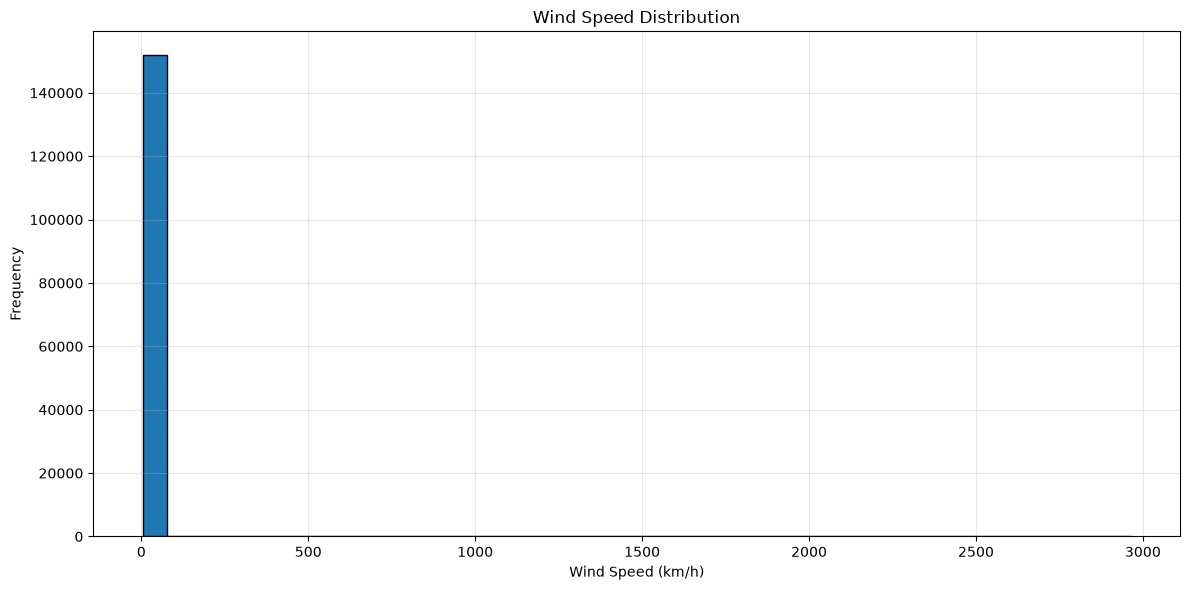

In [137]:
plot_histogram(
    df=df,
    column="wind_kph",
    title="Wind Speed Distribution",
    xlabel="Wind Speed (km/h)",
    filename="wind_speed_distribution.png",
)

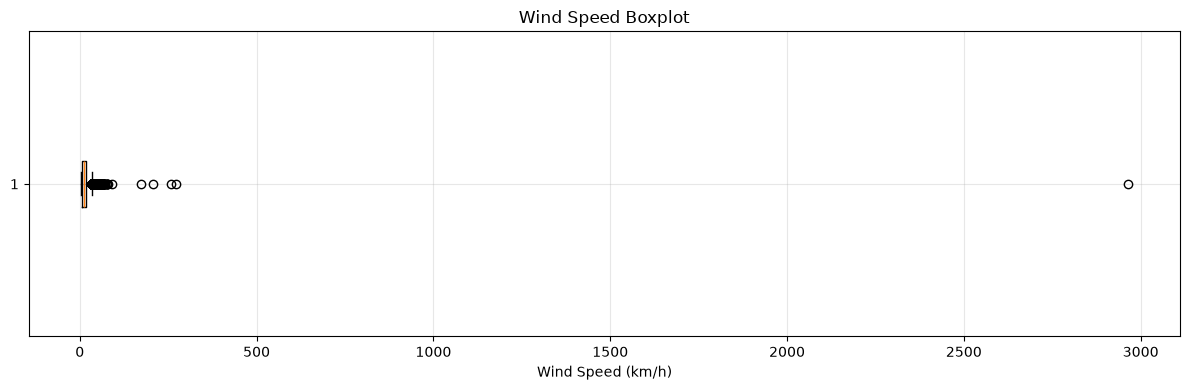

In [138]:
plot_boxplot(
    df=df,
    column="wind_kph",
    title="Wind Speed Boxplot",
    xlabel="Wind Speed (km/h)",
    filename="wind_speed_boxplot.png",
)

In [139]:
numerical_summary(
    df,
    "wind_kph",
)

count    151827.000000
mean         12.784579
std          11.282857
min           3.600000
25%           6.100000
50%          10.800000
75%          17.600000
max        2963.200000
Name: wind_kph, dtype: float64

In [140]:
wind = df["wind_kph"]

print(f"Mean: {wind.mean():.2f} km/h")
print(f"Median: {wind.median():.2f} km/h")
print(f"Standard Deviation: {wind.std():.2f}")
print(f"Minimum: {wind.min():.2f} km/h")
print(f"Maximum: {wind.max():.2f} km/h")
print(f"Skewness: {wind.skew():.2f}")
print(f"Kurtosis: {wind.kurtosis():.2f}")

Mean: 12.78 km/h
Median: 10.80 km/h
Standard Deviation: 11.28
Minimum: 3.60 km/h
Maximum: 2963.20 km/h
Skewness: 118.43
Kurtosis: 30800.82


### Interpretation

#### Distribution

The wind speed distribution is highly right-skewed, with the vast majority of observations concentrated below 20 km/h. This is confirmed by the large positive skewness (118.43), indicating that a small number of extremely large values create a long right tail. The median wind speed (10.8 km/h) is lower than the mean (12.78 km/h), further reflecting the influence of these extreme observations.

#### Outliers

The boxplot reveals numerous extreme outliers, including a maximum recorded wind speed of 2963.2 km/h. This value is not physically realistic and strongly suggests the presence of erroneous or corrupted observations within the dataset. These records should be investigated and treated during the feature engineering phase rather than removed during exploratory analysis.

#### Statistical Characteristics

The dataset contains 151,827 wind speed observations with a standard deviation of 11.28 km/h. While most observations fall within a relatively narrow range, the extreme maximum value substantially inflates the skewness and kurtosis (30,800.82), indicating a heavy-tailed distribution dominated by a few anomalous observations.

#### Modeling Implications

Because of the extreme outliers, wind speed will require additional preprocessing before model training. Potential approaches include outlier detection, winsorization, capping unrealistic values based on meteorological thresholds, or applying robust scaling techniques. These transformations will help improve model stability without discarding legitimate weather variability.

### Key Insights

- Most recorded wind speeds fall below 20 km/h, indicating generally calm atmospheric conditions.
- The distribution is extremely right-skewed due to a small number of exceptionally large observations.
- The maximum recorded value of 2963.2 km/h is physically implausible and should be treated as a data anomaly.
- Wind speed requires targeted preprocessing before predictive modeling.
- Robust preprocessing techniques will likely improve forecasting performance while preserving realistic variability.

# 4. Pressure Analysis

## Objective

Atmospheric pressure is a fundamental meteorological variable that influences weather systems, storm formation, and temperature changes. Analyzing its distribution helps identify variability, potential anomalies, and whether the feature requires preprocessing before predictive modeling.

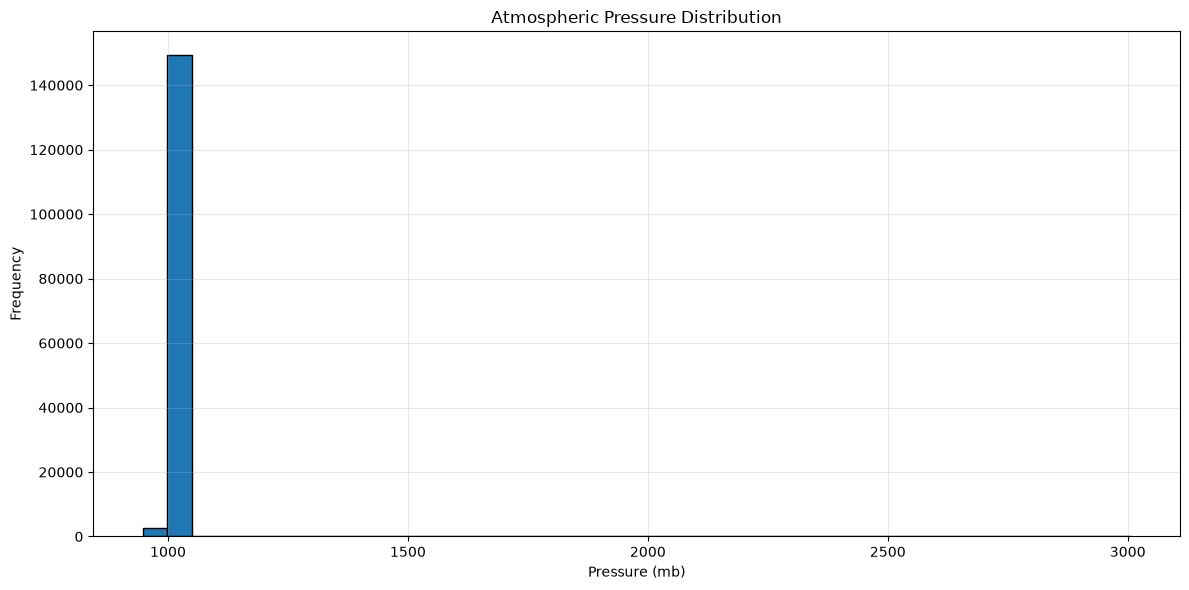

In [141]:
plot_histogram(
    df=df,
    column="pressure_mb",
    title="Atmospheric Pressure Distribution",
    xlabel="Pressure (mb)",
    filename="pressure_distribution.png",
)

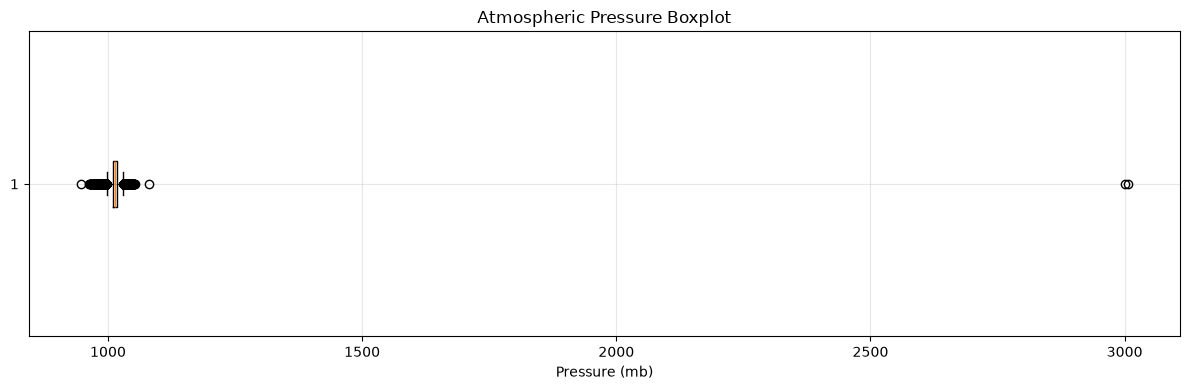

In [142]:
plot_boxplot(
    df=df,
    column="pressure_mb",
    title="Atmospheric Pressure Boxplot",
    xlabel="Pressure (mb)",
    filename="pressure_boxplot.png",
)

In [143]:
numerical_summary(
    df,
    "pressure_mb",
)

count    151827.000000
mean       1014.063329
std           9.985458
min         947.000000
25%        1010.000000
50%        1014.000000
75%        1018.000000
max        3006.000000
Name: pressure_mb, dtype: float64

In [144]:
pressure = df["pressure_mb"]

print(f"Mean: {pressure.mean():.2f} mb")
print(f"Median: {pressure.median():.2f} mb")
print(f"Standard Deviation: {pressure.std():.2f}")
print(f"Minimum: {pressure.min():.2f} mb")
print(f"Maximum: {pressure.max():.2f} mb")
print(f"Skewness: {pressure.skew():.2f}")
print(f"Kurtosis: {pressure.kurtosis():.2f}")

Mean: 1014.06 mb
Median: 1014.00 mb
Standard Deviation: 9.99
Minimum: 947.00 mb
Maximum: 3006.00 mb
Skewness: 104.11
Kurtosis: 20733.81


### Interpretation

#### Distribution

Atmospheric pressure is tightly concentrated around standard sea-level pressure, with most observations falling between approximately 1010 mb and 1018 mb. Although the majority of the data follows a nearly symmetric distribution, the presence of one extremely large value (3006 mb) results in a highly positive skewness (104.11) and extremely high kurtosis.

#### Outliers

The boxplot reveals a small number of extreme outliers, including a maximum pressure of 3006 mb. This value is not physically realistic under Earth's atmospheric conditions and is likely the result of a measurement or data recording error. Aside from these anomalies, pressure measurements remain remarkably consistent.

#### Statistical Characteristics

The dataset contains 151,827 pressure observations with a mean of 1014.06 mb and a standard deviation of only 9.99 mb, indicating very little natural variability. Nearly all observations lie within the expected atmospheric pressure range.

#### Modeling Implications

Atmospheric pressure appears to be a stable and informative predictor for forecasting models. However, unrealistic pressure values should be identified and corrected during feature engineering to prevent them from influencing model training.

### Key Insights

- Atmospheric pressure remains highly stable across the dataset.
- Most observations fall close to standard sea-level pressure.
- A maximum value of 3006 mb is physically implausible and should be treated as a data anomaly.
- Pressure is expected to be a reliable predictive feature after anomaly handling.

# 5. Visibility Analysis

## Objective

Visibility is an important indicator of atmospheric conditions and is often affected by precipitation, fog, dust, and pollution. Understanding its distribution helps evaluate its usefulness as a predictive feature in weather forecasting models.

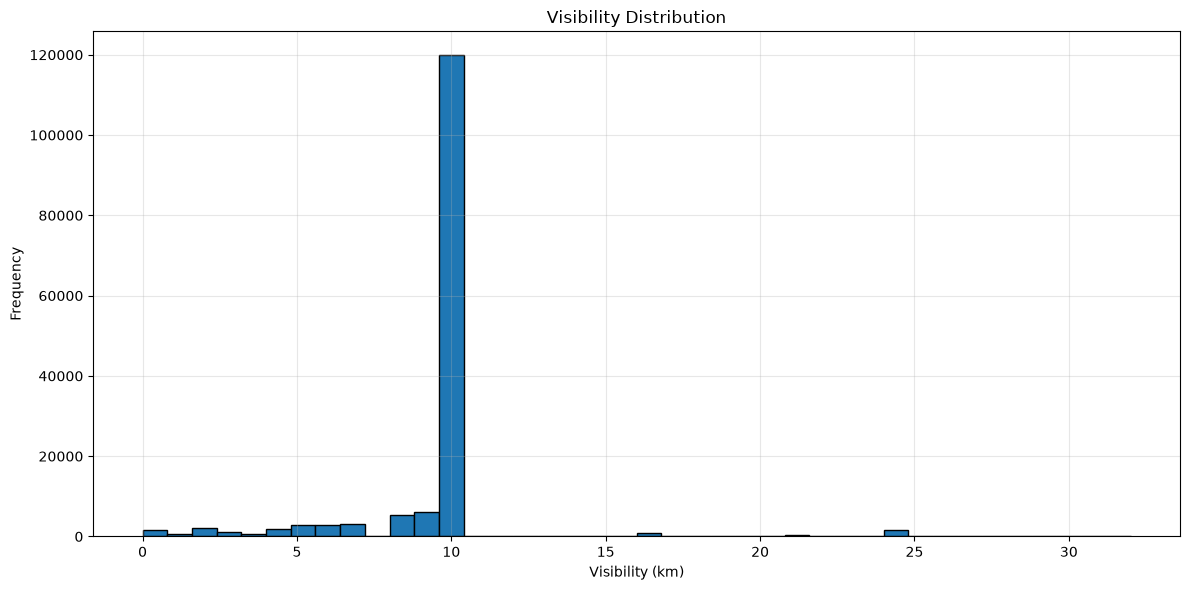

In [145]:
plot_histogram(
    df=df,
    column="visibility_km",
    title="Visibility Distribution",
    xlabel="Visibility (km)",
    filename="visibility_distribution.png",
)

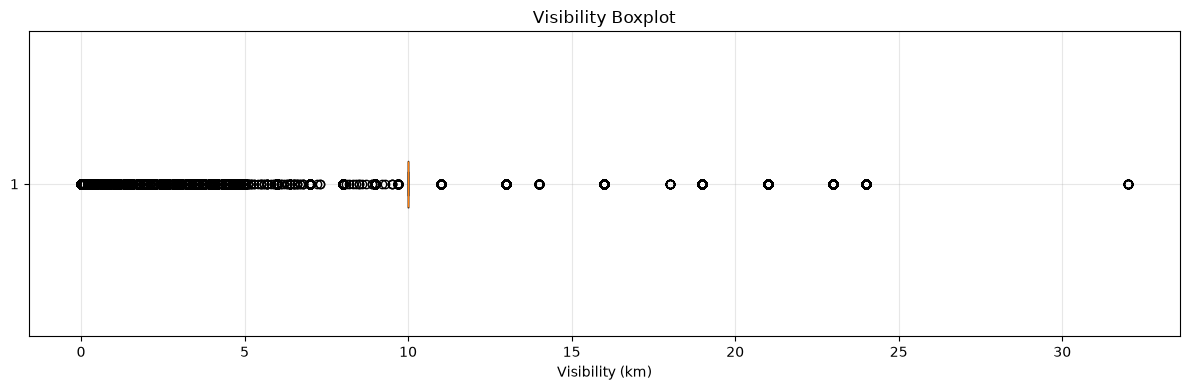

In [146]:
plot_boxplot(
    df=df,
    column="visibility_km",
    title="Visibility Boxplot",
    xlabel="Visibility (km)",
    filename="visibility_boxplot.png",
)

In [147]:
numerical_summary(
    df,
    "visibility_km",
)

count    151827.000000
mean          9.517666
std           2.687121
min           0.000000
25%          10.000000
50%          10.000000
75%          10.000000
max          32.000000
Name: visibility_km, dtype: float64

In [148]:
visibility = df["visibility_km"]

print(f"Mean: {visibility.mean():.2f} km")
print(f"Median: {visibility.median():.2f} km")
print(f"Standard Deviation: {visibility.std():.2f}")
print(f"Minimum: {visibility.min():.2f} km")
print(f"Maximum: {visibility.max():.2f} km")
print(f"Skewness: {visibility.skew():.2f}")
print(f"Kurtosis: {visibility.kurtosis():.2f}")

Mean: 9.52 km
Median: 10.00 km
Standard Deviation: 2.69
Minimum: 0.00 km
Maximum: 32.00 km
Skewness: 1.06
Kurtosis: 12.83


### Interpretation

#### Distribution

Visibility measurements are strongly concentrated around 10 km, indicating that clear atmospheric conditions are common throughout the dataset. The distribution exhibits moderate positive skewness (1.06), reflecting occasional observations with exceptionally high visibility.

#### Outliers

The boxplot identifies several observations above 10 km, extending to a maximum of 32 km. These values are physically plausible and likely represent exceptionally clear atmospheric conditions rather than measurement errors.

#### Statistical Characteristics

Visibility has a mean of 9.52 km and a relatively small standard deviation of 2.69 km, indicating limited variability across observations. The majority of measurements cluster tightly around the median value of 10 km.

#### Modeling Implications

Visibility appears to be a well-behaved feature with no obvious data quality issues. Its stability and realistic value range suggest it can be incorporated directly into forecasting models with minimal preprocessing.

### Key Insights

- Most observations report visibility close to 10 km.
- The distribution shows moderate positive skewness due to exceptionally clear conditions.
- No unrealistic visibility measurements were identified.
- Visibility appears suitable for direct use during model development.

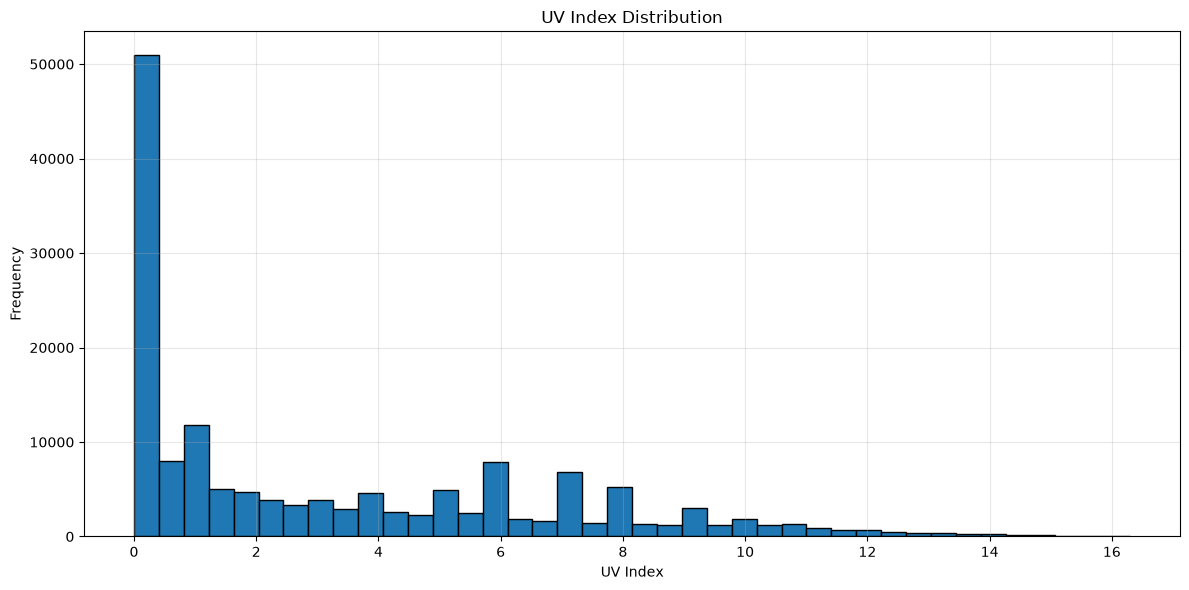

In [149]:
plot_histogram(
    df=df,
    column="uv_index",
    title="UV Index Distribution",
    xlabel="UV Index",
    filename="uv_distribution.png",
)

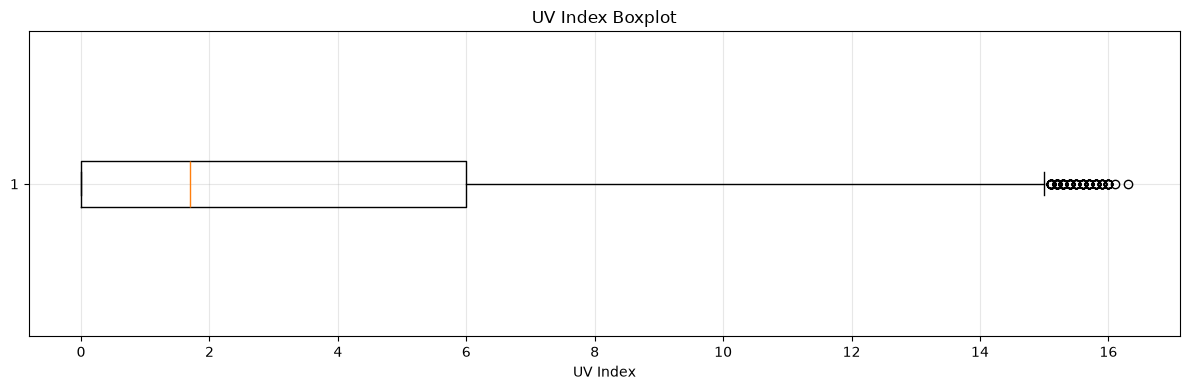

In [150]:
plot_boxplot(
    df=df,
    column="uv_index",
    title="UV Index Boxplot",
    xlabel="UV Index",
    filename="uv_boxplot.png",
)

In [151]:
numerical_summary(
    df,
    "uv_index",
)

count    151827.000000
mean          3.203804
std           3.514529
min           0.000000
25%           0.000000
50%           1.700000
75%           6.000000
max          16.300000
Name: uv_index, dtype: float64

In [152]:
uv = df["uv_index"]

print(f"Mean: {uv.mean():.2f}")
print(f"Median: {uv.median():.2f}")
print(f"Standard Deviation: {uv.std():.2f}")
print(f"Minimum: {uv.min():.2f}")
print(f"Maximum: {uv.max():.2f}")
print(f"Skewness: {uv.skew():.2f}")
print(f"Kurtosis: {uv.kurtosis():.2f}")

Mean: 3.20
Median: 1.70
Standard Deviation: 3.51
Minimum: 0.00
Maximum: 16.30
Skewness: 0.96
Kurtosis: -0.05


### Interpretation

#### Distribution

The UV Index distribution is moderately right-skewed, with low UV values occurring most frequently. The median UV Index of 1.7 indicates that many observations correspond to nighttime, cloudy conditions, or locations with limited solar intensity.

#### Outliers

Several observations exceed a UV Index of 14, reaching a maximum of 16.3. These values are uncommon but remain physically realistic in regions with intense sunlight and favorable atmospheric conditions.

#### Statistical Characteristics

The dataset exhibits moderate variability, with a mean UV Index of 3.20 and a standard deviation of 3.51. The relatively low kurtosis indicates that the distribution does not contain excessively heavy tails.

#### Modeling Implications

The UV Index captures meaningful environmental variability and should provide useful predictive information. Since all observed values remain within realistic limits, extensive preprocessing is unlikely to be necessary.

### Key Insights

- Low UV Index values dominate the dataset.
- Moderate right skew reflects occasional periods of intense sunlight.
- No unrealistic UV measurements were observed.
- UV Index is expected to be a useful environmental predictor.

# 7. Precipitation Analysis

## Objective

Precipitation is one of the primary indicators of weather conditions and plays an essential role in forecasting rainfall events. This section examines the distribution, variability, and presence of extreme precipitation values.

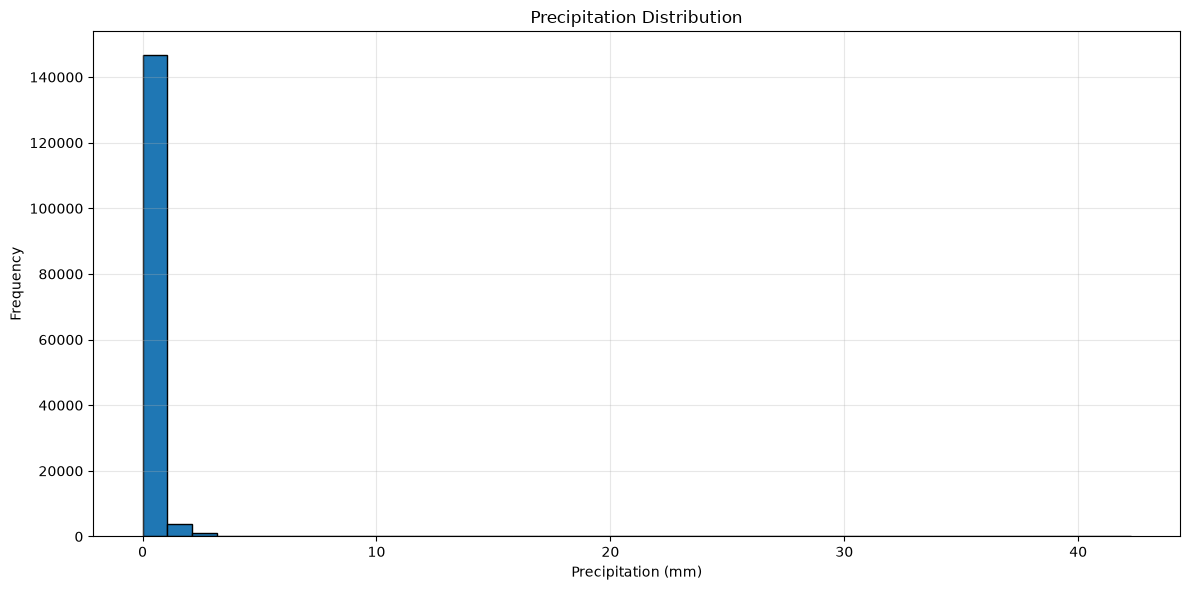

In [153]:
plot_histogram(
    df=df,
    column="precip_mm",
    title="Precipitation Distribution",
    xlabel="Precipitation (mm)",
    filename="precipitation_distribution.png",
)

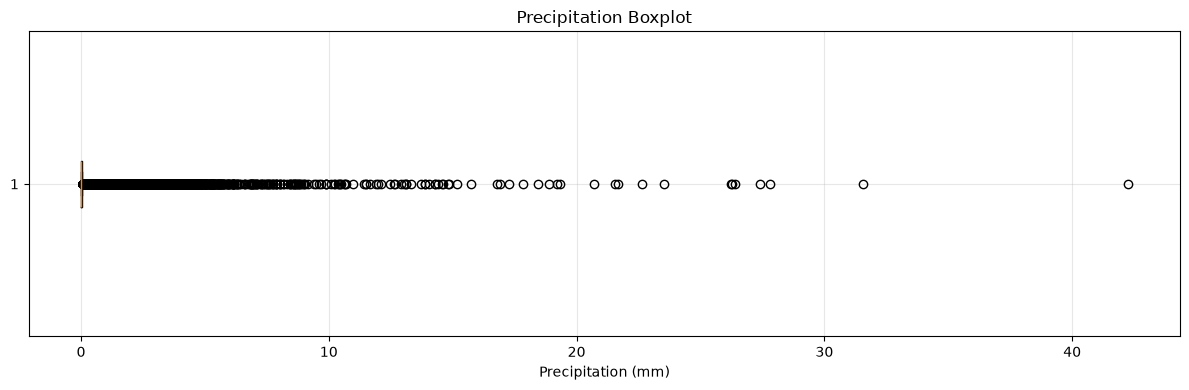

In [154]:
plot_boxplot(
    df=df,
    column="precip_mm",
    title="Precipitation Boxplot",
    xlabel="Precipitation (mm)",
    filename="precipitation_boxplot.png",
)

In [155]:
numerical_summary(
    df,
    "precip_mm",
)

count    151827.000000
mean          0.131680
std           0.556364
min           0.000000
25%           0.000000
50%           0.000000
75%           0.020000
max          42.240000
Name: precip_mm, dtype: float64

In [156]:
precip = df["precip_mm"]

print(f"Mean: {precip.mean():.2f} mm")
print(f"Median: {precip.median():.2f} mm")
print(f"Standard Deviation: {precip.std():.2f}")
print(f"Minimum: {precip.min():.2f} mm")
print(f"Maximum: {precip.max():.2f} mm")
print(f"Skewness: {precip.skew():.2f}")
print(f"Kurtosis: {precip.kurtosis():.2f}")

Mean: 0.13 mm
Median: 0.00 mm
Standard Deviation: 0.56
Minimum: 0.00 mm
Maximum: 42.24 mm
Skewness: 18.19
Kurtosis: 698.61


### Interpretation

#### Distribution

Precipitation is heavily concentrated at zero, indicating that most observations correspond to dry weather conditions. The extremely large positive skewness (18.19) reflects the relatively small number of heavy rainfall events that extend the upper tail of the distribution.

#### Outliers

The boxplot identifies numerous high precipitation observations, with a maximum of 42.24 mm. These values are physically plausible and likely represent genuine heavy rainfall events rather than data quality issues.

#### Statistical Characteristics

The mean precipitation is only 0.13 mm, while the median is 0 mm, confirming that rainfall is absent for at least half of all observations. The large kurtosis reflects the rarity of significant precipitation events.

#### Modeling Implications

Precipitation exhibits a highly zero-inflated distribution that is characteristic of meteorological datasets. This feature may benefit from transformations or specialized feature engineering techniques, such as binary rainfall indicators or logarithmic transformations, depending on the modeling approach.

### Key Insights

- Most observations recorded no measurable precipitation.
- Rainfall events are relatively rare but occasionally intense.
- The distribution is highly zero-inflated and strongly right-skewed.
- Specialized preprocessing may improve predictive performance for precipitation-related models.

# 8. Weather Condition Analysis

## Objective

Weather condition labels summarize the overall atmospheric state observed at each location. Understanding the frequency of different weather conditions provides insight into class balance, identifies dominant weather patterns, and helps determine whether future prediction tasks may suffer from class imbalance.

In [157]:
condition_counts = (
    df["condition_text"]
    .value_counts()
    .sort_values(ascending=False)
)

condition_counts.head(15)

condition_text
Sunny                                  44300
Partly cloudy                          42052
Patchy rain nearby                     13043
Partly Cloudy                          10208
Clear                                   8237
Overcast                                8115
Mist                                    6229
Light rain                              4659
Light rain shower                       3494
Fog                                     1900
Cloudy                                  1879
Moderate or heavy rain with thunder     1179
Moderate rain                           1111
Patchy light rain with thunder           930
Light drizzle                            751
Name: count, dtype: int64

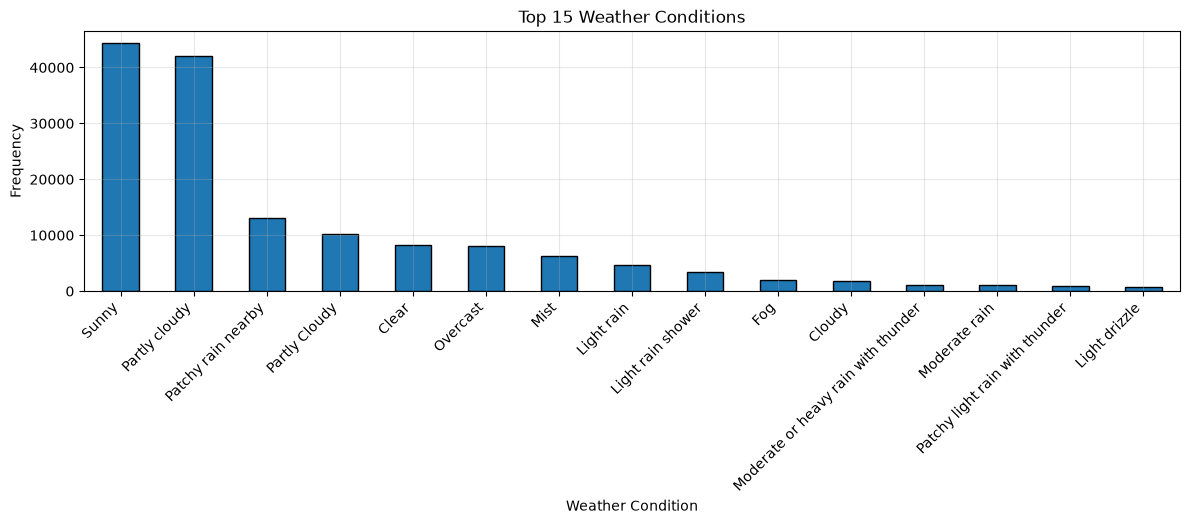

In [158]:
plot_bar_chart(
    data=condition_counts.head(15),
    title="Top 15 Weather Conditions",
    xlabel="Weather Condition",
    ylabel="Frequency",
    filename="weather_conditions.png",
)

In [159]:
print(f"Unique weather conditions: {df['condition_text'].nunique()}")

print()

print(condition_counts.describe())

Unique weather conditions: 57

count       57.000000
mean      2663.631579
std       8258.569886
min          1.000000
25%         14.000000
50%         67.000000
75%        751.000000
max      44300.000000
Name: count, dtype: float64


### Interpretation

#### Distribution

The dataset contains **57 unique weather condition categories**. The distribution is highly imbalanced, with a small number of conditions accounting for the majority of observations while many categories occur only infrequently.

#### Dominant Weather Conditions

Sunny (44,300 observations) and Partly cloudy (42,052 observations) are the most common weather conditions, followed by Patchy rain nearby, Clear, and Overcast. These results indicate that fair-weather conditions dominate the dataset.

An inconsistency was also identified in the categorical labels: both "Partly cloudy" and "Partly Cloudy" appear as separate categories, indicating inconsistent capitalization within the raw dataset. This issue will be addressed during feature engineering through categorical standardization.

#### Modeling Implications

The strong class imbalance may influence any future classification tasks involving weather conditions. Rare categories may require grouping, resampling, or class weighting to improve predictive performance. Standardizing categorical labels will also reduce unnecessary category fragmentation.

### Key Insights

- The dataset contains 57 unique weather condition categories.
- Sunny and Partly cloudy account for the largest proportion of observations.
- The distribution is highly imbalanced, with many rare weather conditions.
- Inconsistent capitalization creates duplicate categories that should be standardized.

# 9. Country Analysis

## Objective

The dataset contains observations collected from multiple countries. Examining their distribution helps evaluate geographic diversity and determine whether the dataset is balanced across regions.

In [160]:
country_counts = (
    df["country"]
    .value_counts()
    .sort_values(ascending=False)
)

country_counts.head(20)

country
Bulgaria        1785
Indonesia       1562
Thailand        1559
Turkey          1555
Sudan           1555
Bolivia         1548
Iran            1515
Belgium         1464
Madagascar      1238
Vietnam         1234
Hungary          895
Russia           834
Switzerland      830
Senegal          814
Norway           788
Kenya            782
Burundi          781
Iraq             781
Uzbekistan       781
Fiji Islands     781
Name: count, dtype: int64

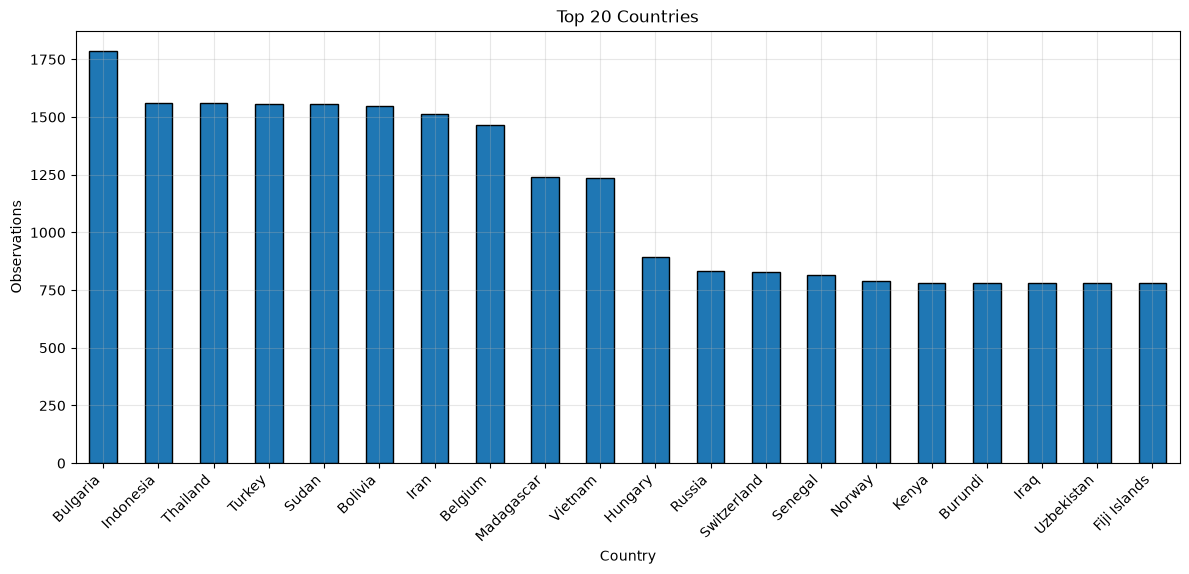

In [161]:
plot_bar_chart(
    data=country_counts.head(20),
    title="Top 20 Countries",
    xlabel="Country",
    ylabel="Observations",
    filename="top_countries.png",
)

In [162]:
print(f"Countries represented: {df['country'].nunique()}")

print()

country_counts.describe()

Countries represented: 211



count     211.000000
mean      719.559242
std       309.132966
min         1.000000
25%       777.000000
50%       779.000000
75%       780.000000
max      1785.000000
Name: count, dtype: float64

### Interpretation

#### Geographic Coverage

The dataset includes observations from **211 countries**, demonstrating broad global coverage across diverse climatic regions. This geographic diversity increases the usefulness of the dataset for developing generalized weather forecasting models.

#### Distribution

Although Bulgaria contains the largest number of observations, the majority of countries contribute between approximately 700 and 800 records. This indicates that the dataset is reasonably balanced despite some variation in country representation.

#### Modeling Implications

The broad international coverage should improve model generalization across different climates. Country may also serve as a valuable categorical feature during feature engineering, either directly or through regional grouping.

### Key Insights

- Observations span 211 countries.
- Geographic diversity supports robust global weather analysis.
- Country representation is relatively balanced, with only modest differences in sample size.
- Country information may provide valuable contextual features for forecasting models.

# 10. Wind Direction Analysis

## Objective

Wind direction influences weather movement and atmospheric circulation. This section examines the frequency of each compass direction to determine whether any directional bias exists within the dataset.

In [163]:
wind_direction_counts = (
    df["wind_direction"]
    .value_counts()
    .sort_index()
)

wind_direction_counts

wind_direction
E      14398
ENE    12430
ESE    10406
N      10054
NE      8759
NNE     9890
NNW     8652
NW      7814
S       9290
SE      8093
SSE     8969
SSW     8958
SW      9054
W       8056
WNW     7965
WSW     9039
Name: count, dtype: int64

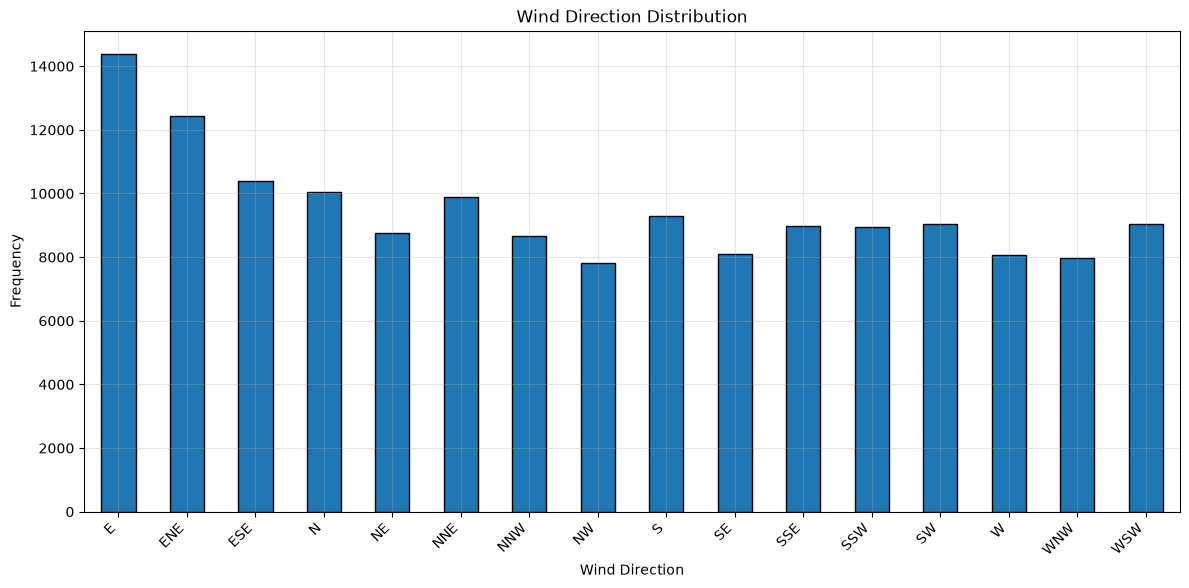

In [164]:
plot_bar_chart(
    data=wind_direction_counts,
    title="Wind Direction Distribution",
    xlabel="Wind Direction",
    ylabel="Frequency",
    filename="wind_direction_distribution.png",
)

### Interpretation

#### Distribution

All sixteen compass directions are represented within the dataset. Eastern wind directions occur more frequently than western directions, suggesting a moderate directional imbalance in the collected observations.

#### Dominant Directions

East (E) is the most common wind direction, followed by East-Northeast (ENE) and East-Southeast (ESE). Western directions occur somewhat less frequently but remain well represented.

#### Modeling Implications

Wind direction contains meaningful meteorological information but is inherently cyclical. During feature engineering, directional encoding techniques such as sine/cosine transformations may better preserve the circular nature of compass directions than simple categorical encoding.

### Key Insights

- All sixteen compass directions are represented.
- Eastern wind directions occur more frequently.
- Wind direction should be treated as a cyclical feature during feature engineering.

# 11. Moon Phase Analysis

## Objective

Although moon phase is unlikely to directly influence short-term weather forecasting, it provides an additional environmental feature that may contribute to exploratory analysis and future feature engineering experiments.

In [165]:
moon_phase_counts = (
    df["moon_phase"]
    .value_counts()
)

moon_phase_counts

moon_phase
Waxing Gibbous     33350
Waning Gibbous     32431
Waning Crescent    32157
Waxing Crescent    32126
Full Moon           5593
Last Quarter        5519
New Moon            5348
First Quarter       5303
Name: count, dtype: int64

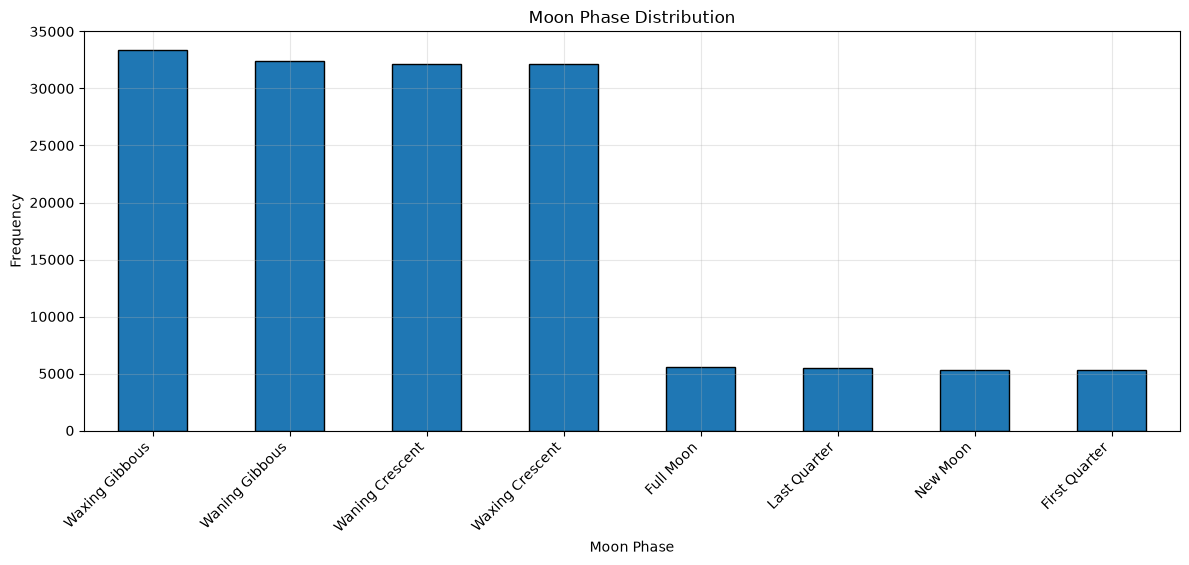

In [166]:
plot_bar_chart(
    data=moon_phase_counts,
    title="Moon Phase Distribution",
    xlabel="Moon Phase",
    ylabel="Frequency",
    filename="moon_phase_distribution.png",
)

### Interpretation

#### Distribution

Eight distinct lunar phases are represented in the dataset. Waxing and waning crescent and gibbous phases account for the majority of observations, while the four principal lunar phases occur less frequently.

#### Observed Pattern

The distribution suggests that intermediate lunar phases dominate the observation period. This likely reflects the unequal duration of lunar phases or the sampling methodology rather than any meteorological phenomenon.

#### Modeling Implications

Moon phase is unlikely to be a primary predictor of short-term weather conditions. Nevertheless, it represents an additional environmental feature that can be evaluated experimentally during feature engineering and model selection.

### Key Insights

- Eight moon phases are represented.
- Crescent and gibbous phases dominate the dataset.
- Moon phase is expected to have limited predictive influence but may provide supplementary environmental context.

# 12. Correlation Analysis

## Objective

Understanding relationships between numerical variables is essential before
developing predictive models. Correlation analysis identifies variables that
move together, reveals potential multicollinearity, and highlights redundant
features that may affect model performance.

This section examines pairwise Pearson correlations among numerical features
to support feature engineering and model selection.

In [167]:
numeric_df = df.select_dtypes(include="number")

print(f"Number of numerical features: {numeric_df.shape[1]}")
numeric_df.columns

Number of numerical features: 30


Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius', 'temperature_fahrenheit', 'wind_mph',
       'wind_kph', 'wind_degree', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud',
       'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph',
       'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='object')

In [168]:
correlation_matrix = numeric_df.corr()

correlation_matrix.head()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
latitude,1.000000,-0.018601,0.004782,-0.367585,-0.367582,0.009144,0.009131,0.151685,0.021076,0.021112,-0.061322,-0.059839,-0.101845,-0.078608,-0.396867,-0.396865,-0.029491,-0.030599,-0.100912,-0.003566,-0.003543,-0.044931,0.125289,0.203934,0.049952,0.002279,0.014595,0.043224,0.036206,-0.000067
longitude,-0.018601,1.000000,-0.004200,0.147751,0.147758,0.048257,0.048160,0.079059,-0.110928,-0.109462,0.064506,0.064905,-0.254289,0.038292,0.151263,0.151264,0.117134,0.115772,0.200364,0.015714,0.015711,0.098529,0.039687,0.133458,0.094523,0.101245,0.042111,0.137188,0.135811,-0.000607
last_updated_epoch,0.004782,-0.004200,1.000000,-0.175659,-0.175652,-0.058658,-0.058657,-0.010830,0.024363,0.024698,-0.024662,-0.024716,0.154847,-0.007318,-0.175793,-0.175714,-0.044610,-0.048456,-0.285505,-0.074057,-0.074074,-0.125960,-0.186837,-0.024864,-0.031614,-0.049577,-0.026840,-0.048755,-0.050414,0.025040
temperature_celsius,-0.367585,0.147751,-0.175659,1.000000,0.999997,0.095601,0.095523,-0.020166,-0.295255,-0.295849,0.034089,0.033997,-0.340417,-0.123174,0.981012,0.981011,0.105281,0.108659,0.485622,0.081016,0.081042,-0.002864,0.250154,-0.134881,-0.031951,0.063350,0.113260,0.095172,0.097585,0.002614
temperature_fahrenheit,-0.367582,0.147758,-0.175652,0.999997,1.000000,0.095613,0.095535,-0.020159,-0.295252,-0.295846,0.034103,0.034011,-0.340413,-0.123164,0.981013,0.981013,0.105286,0.108662,0.485623,0.081027,0.081052,-0.002863,0.250154,-0.134871,-0.031948,0.063357,0.113263,0.095178,0.097590,0.002617


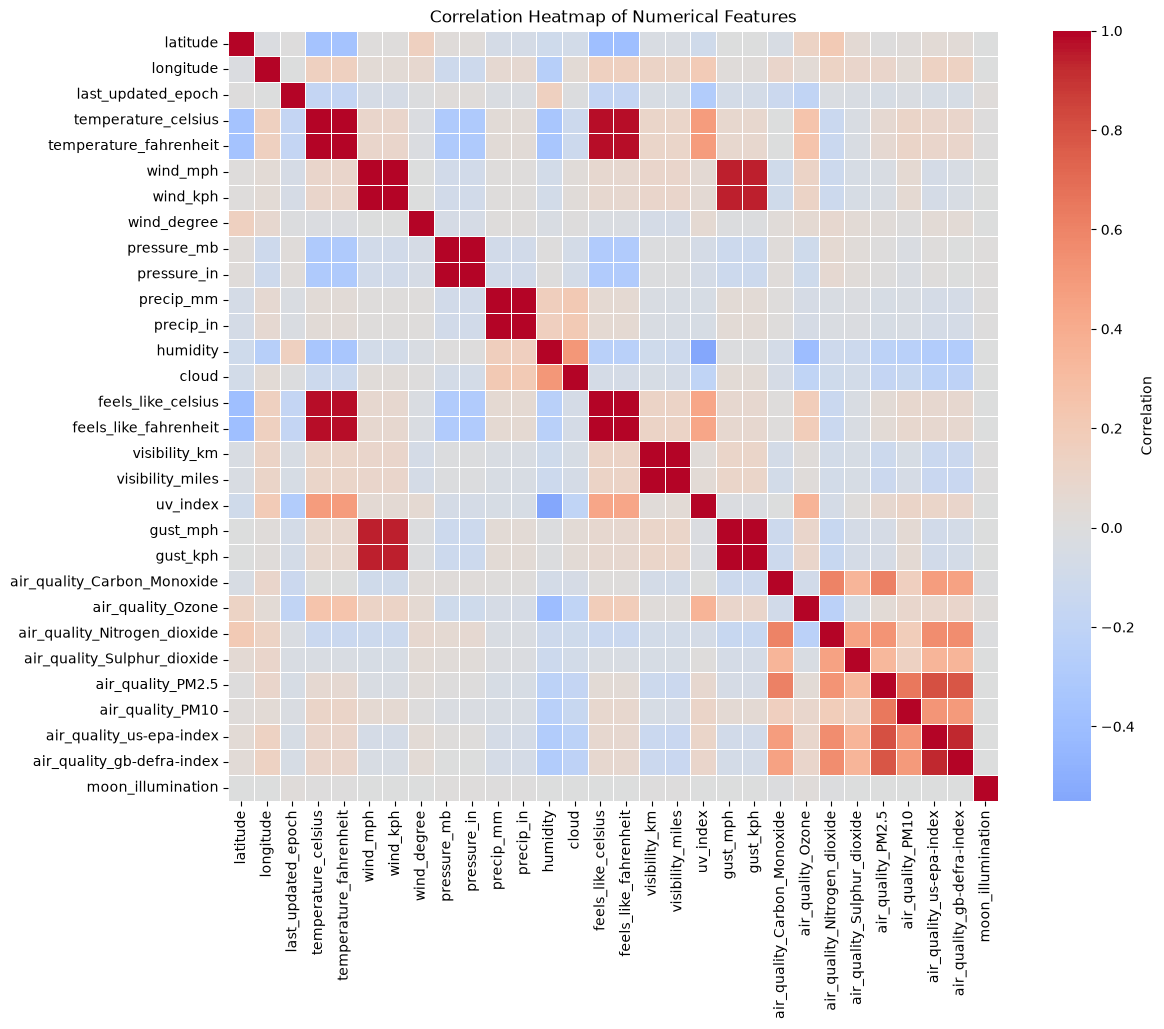

In [169]:
plot_correlation_heatmap(
    df=df,
    title="Correlation Heatmap of Numerical Features",
    filename="correlation_heatmap.png",
)

In [170]:
high_corr = get_high_correlations(
    df=df,
    threshold=0.80,
)

high_corr.head(20)

,Feature 1,Feature 2,Correlation
0,temperature_celsius,temperature_fahrenheit,0.999997
1,feels_like_celsius,feels_like_fahrenheit,0.999996
2,gust_mph,gust_kph,0.999992
3,wind_mph,wind_kph,0.999988
4,pressure_mb,pressure_in,0.999794
5,precip_mm,precip_in,0.997924
6,visibility_km,visibility_miles,0.992508
7,temperature_fahrenheit,feels_like_celsius,0.981013
8,temperature_fahrenheit,feels_like_fahrenheit,0.981013
9,temperature_celsius,feels_like_celsius,0.981012


In [171]:
print(f"Highly correlated feature pairs: {len(high_corr)}")

Highly correlated feature pairs: 17


### Correlation Heatmap Interpretation

The correlation heatmap provides a comprehensive overview of the linear relationships among all numerical variables in the dataset. Strong positive correlations appear as deep red cells, while strong negative correlations appear as blue cells.

Several nearly perfect positive correlations are observed between variables that represent the same physical measurements in different units. For example:

- **Temperature (°C)** and **Temperature (°F)** exhibit an almost perfect positive correlation.
- **Wind Speed (km/h)** and **Wind Speed (mph)** are nearly perfectly correlated.
- **Pressure (mb)** and **Pressure (in)** display an almost identical relationship.
- **Visibility (km)** and **Visibility (miles)** are also highly correlated.
- **Feels Like Temperature** variables are strongly correlated with the measured air temperature.

These relationships are expected because they represent unit conversions or directly derived variables rather than independent measurements. Such variables should not be used together during model training because they introduce redundancy and may lead to multicollinearity or target leakage.

Among the independent meteorological variables, several meaningful relationships are evident. UV Index shows a moderate positive association with temperature, while humidity, atmospheric pressure, and latitude exhibit moderate negative relationships. Air quality indicators display varying degrees of correlation with one another, suggesting that they capture related aspects of atmospheric conditions.

Overall, the heatmap confirms that the dataset contains both highly redundant variables and informative independent predictors. These findings will guide feature selection during the feature engineering phase by identifying variables that should be retained, transformed, or removed before model development.

# 13. Bivariate Analysis

## Objective

While univariate analysis describes individual variables independently, bivariate analysis explores relationships between pairs of variables. Understanding these relationships helps identify meaningful patterns that may improve predictive performance during model development.

## 13.1 Temperature vs Humidity

### Objective

Temperature and humidity are two of the most influential meteorological variables. Understanding their relationship helps determine whether higher temperatures are generally associated with lower humidity levels, which is common in many climates.

A scatter plot is used to visualize the relationship between these variables.

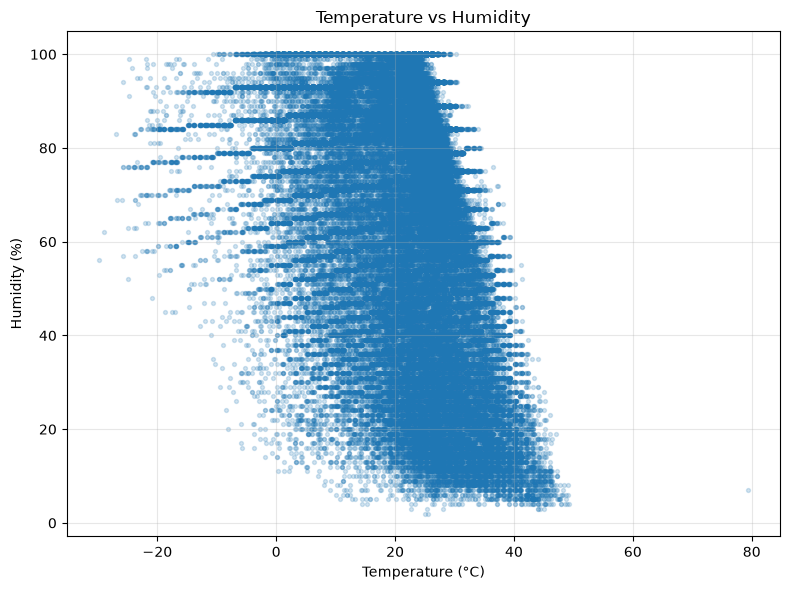

In [174]:
plot_scatter(
    df=df,
    x="temperature_celsius",
    y="humidity",
    title="Temperature vs Humidity",
    xlabel="Temperature (°C)",
    ylabel="Humidity (%)",
    filename="temperature_vs_humidity.png",
)

In [175]:
temp_humidity_corr = df["temperature_celsius"].corr(df["humidity"])

print(f"Pearson Correlation: {temp_humidity_corr:.3f}")

Pearson Correlation: -0.340


### Interpretation

The scatter plot illustrates the relationship between temperature and humidity across all weather observations. While individual observations are widely dispersed, an overall downward trend is visible.

The Pearson correlation coefficient is **-0.340**, indicating a **weak-to-moderate negative linear relationship** between temperature and humidity. This suggests that, on average, humidity tends to decrease as temperature increases. Although the relationship is not particularly strong, it is consistent with meteorological principles, where warmer air can hold more moisture, often resulting in lower relative humidity.

The noticeable spread of points indicates that humidity is influenced by many additional factors beyond temperature alone, including geographic location, seasonality, altitude, and prevailing weather systems. Consequently, humidity should be considered an informative feature but not a sole predictor when developing forecasting models.

Overall, the observed relationship confirms that humidity is likely to contribute useful predictive information during feature engineering and machine learning model development.

## 13.2 Temperature vs Wind Speed

### Objective

Wind speed plays an important role in atmospheric processes, influencing heat transfer, evaporation, and perceived temperature. This analysis investigates whether higher temperatures are associated with stronger or weaker winds across the global dataset.

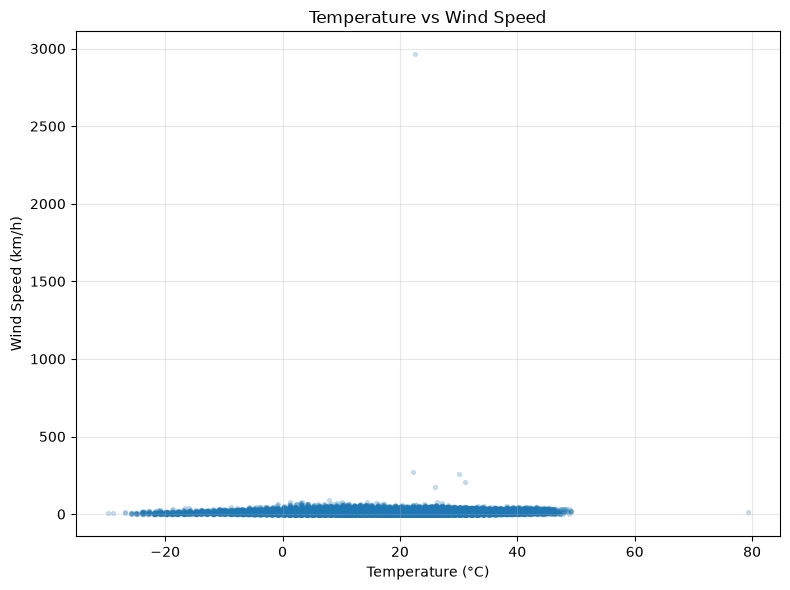

In [176]:
plot_scatter(
    df=df,
    x="temperature_celsius",
    y="wind_kph",
    title="Temperature vs Wind Speed",
    xlabel="Temperature (°C)",
    ylabel="Wind Speed (km/h)",
    filename="temperature_vs_wind_speed.png",
)

In [177]:
temp_wind_corr = df["temperature_celsius"].corr(df["wind_kph"])

print(f"Pearson Correlation: {temp_wind_corr:.3f}")

Pearson Correlation: 0.096


### Interpretation

The scatter plot shows the relationship between temperature and wind speed across all weather observations. Most observations are concentrated below **100 km/h**, while temperatures span a broad range from approximately **−25 °C to 45 °C**. A extreme wind speed value, reaching nearly **3000 km/h**, is clearly visible and is likely the result of measurement errors or anomalous records identified earlier during exploratory analysis.

The Pearson correlation coefficient is **0.096**, indicating an **extremely weak positive linear relationship** between temperature and wind speed. This suggests that changes in temperature are associated with only negligible changes in wind speed, and no meaningful linear trend exists between the two variables.

The broad dispersion of points further demonstrates that wind speed varies independently of temperature in most observations. Wind speed is influenced by numerous atmospheric processes, including pressure gradients, terrain, and regional weather systems, rather than temperature alone.

Overall, wind speed is unlikely to serve as a strong standalone predictor of temperature. However, it may still provide useful information when combined with other meteorological variables in multivariate machine learning models.

## 13.3 Temperature vs Atmospheric Pressure

### Objective

Atmospheric pressure is an important indicator of weather systems and is often associated with changes in temperature. This analysis investigates whether a relationship exists between temperature and atmospheric pressure across the global weather dataset.

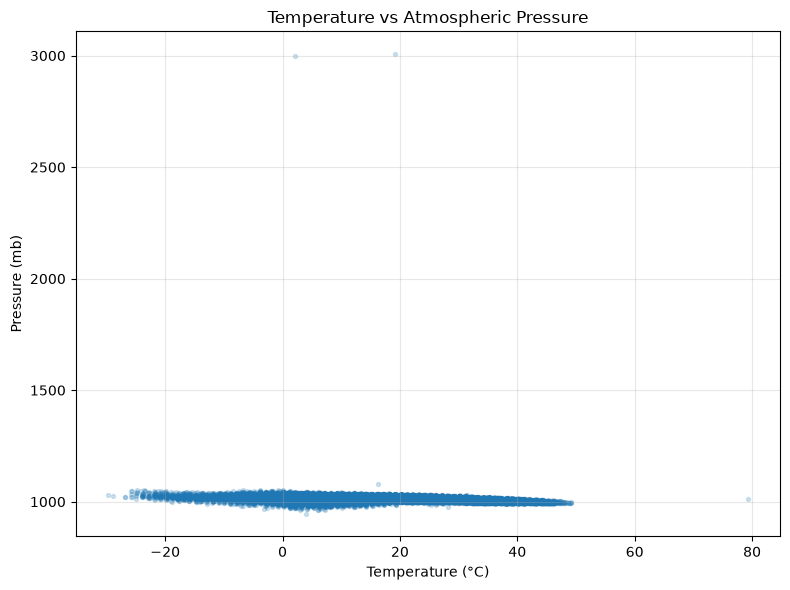

In [178]:
plot_scatter(
    df=df,
    x="temperature_celsius",
    y="pressure_mb",
    title="Temperature vs Atmospheric Pressure",
    xlabel="Temperature (°C)",
    ylabel="Pressure (mb)",
    filename="temperature_vs_pressure.png",
)

In [179]:
temp_pressure_corr = df["temperature_celsius"].corr(df["pressure_mb"])

print(f"Pearson Correlation: {temp_pressure_corr:.3f}")

Pearson Correlation: -0.295


### Interpretation

The scatter plot illustrates the relationship between temperature and atmospheric pressure across all weather observations. Most observations are concentrated within the normal atmospheric pressure range of approximately **950–1050 mb**, while temperatures vary from roughly **−25 °C to 45 °C**. A small number of extreme pressure values approaching **3000 mb** are visible and are likely anomalous measurements identified during earlier exploratory analysis.

The Pearson correlation coefficient is **−0.295**, indicating a **weak negative linear relationship** between temperature and atmospheric pressure. This suggests that atmospheric pressure tends to decrease slightly as temperature increases, although the relationship is not sufficiently strong to indicate direct dependence.

The wide spread of observations demonstrates that atmospheric pressure is influenced by many additional factors, including weather systems, altitude, and regional climatic conditions. Consequently, pressure alone is not a strong predictor of temperature, but it may provide valuable complementary information when combined with other meteorological variables.

Overall, atmospheric pressure appears to be a useful supporting feature for predictive modeling, particularly when incorporated into multivariate forecasting algorithms.

## 13.4 Temperature vs Visibility

### Objective

Visibility is influenced by several atmospheric conditions, including precipitation, fog, humidity, and airborne particles. This analysis investigates whether visibility exhibits any meaningful relationship with temperature across the global weather dataset.

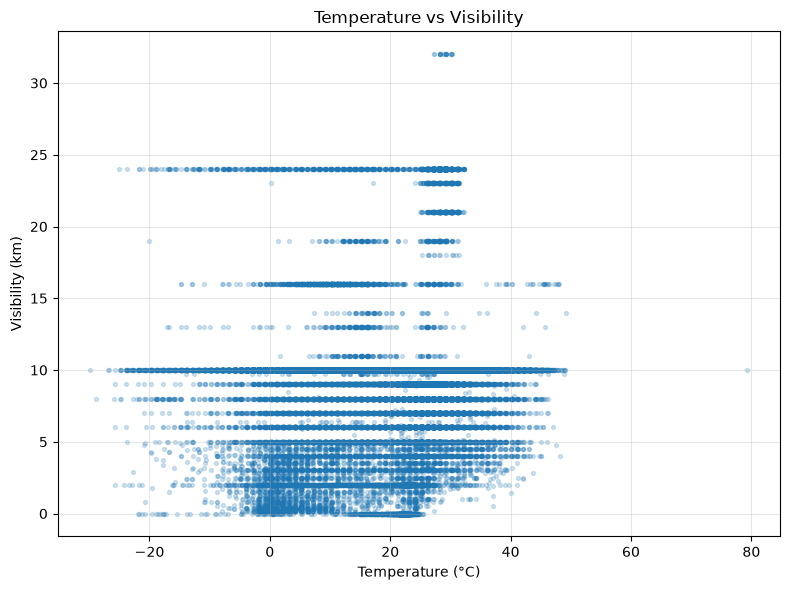

In [180]:
plot_scatter(
    df=df,
    x="temperature_celsius",
    y="visibility_km",
    title="Temperature vs Visibility",
    xlabel="Temperature (°C)",
    ylabel="Visibility (km)",
    filename="temperature_vs_visibility.png",
)

In [181]:
temp_visibility_corr = df["temperature_celsius"].corr(df["visibility_km"])

print(f"Pearson Correlation: {temp_visibility_corr:.3f}")

Pearson Correlation: 0.105


### Interpretation

The scatter plot illustrates the relationship between temperature and visibility across all weather observations. Temperatures range from approximately **−25 °C to 45 °C**, while visibility extends from **0 km to 32 km**. Most observations are concentrated between **0 km and 10 km** of visibility across nearly the entire temperature range, indicating that visibility remains relatively consistent regardless of temperature.

Distinct horizontal bands appear at common visibility values such as **5 km, 10 km, 15 km, and 25 km**, suggesting that visibility measurements are frequently recorded using standardized reporting intervals rather than continuous values.

The Pearson correlation coefficient is **0.105**, indicating an **extremely weak positive linear relationship** between temperature and visibility. Although visibility increases slightly with higher temperatures on average, the relationship is too weak to be considered a meaningful standalone predictor.

The broad distribution of observations demonstrates that visibility is influenced primarily by other atmospheric factors, including precipitation, fog, humidity, airborne particles, and local weather conditions. Consequently, visibility should be treated as a complementary feature rather than a primary predictor in forecasting models.

Overall, visibility contributes useful contextual information but is unlikely to substantially improve predictive performance unless combined with additional meteorological variables.

## 13.5 Geographic Distribution

### Objective

Since the dataset contains observations from numerous countries around the world, it is useful to visualize their geographic distribution using latitude and longitude coordinates. This analysis provides an overview of the spatial coverage of the dataset and helps identify any regions with higher concentrations of observations.

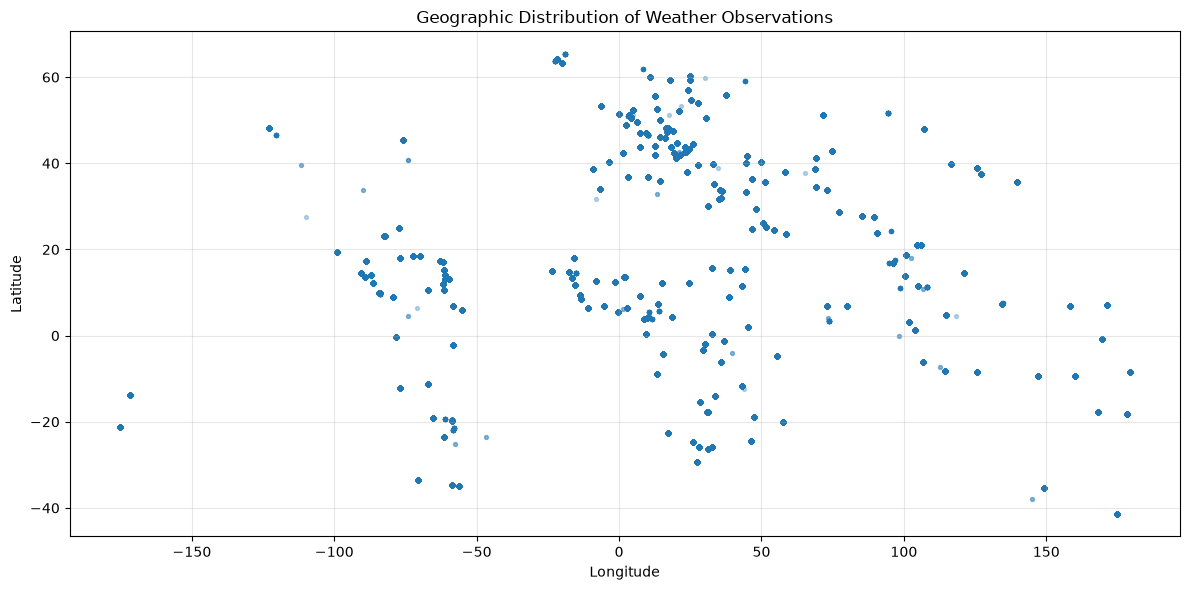

In [182]:
plot_scatter_map(
    df=df,
    title="Geographic Distribution of Weather Observations",
    filename="geographic_distribution.png",
)

### Interpretation

The geographic scatter plot illustrates the spatial distribution of weather observations using latitude and longitude coordinates. The dataset exhibits broad global coverage, with observations spanning nearly the entire longitude range (approximately −180° to +180°) and covering multiple continents. However, observations are not uniformly distributed, with relatively few data points in the polar regions and across large oceanic areas.

Several clear clusters of observations are visible over Europe, North America, Southeast Asia, and portions of South America and Africa, indicating that certain geographic regions contain a higher concentration of recorded weather observations. In contrast, open oceans and extreme northern and southern latitudes contain comparatively fewer observations.

The latitude and longitude values fall within valid geographic ranges, and no obvious coordinate anomalies or invalid locations are apparent. Overall, the spatial distribution appears realistic and consistent with a globally collected weather dataset.

The uneven geographic distribution suggests that some regions are more heavily represented than others. This should be considered during model development, as geographic sampling density may influence model performance and generalization across different parts of the world.

## 13.6 Correlation Summary

### Objective

This section summarizes the strongest relationships identified during exploratory data analysis. Understanding these relationships helps identify informative predictors and provides insight into which variables may contribute most to temperature forecasting models.

In [183]:
# Correlations with the target variable

target = "temperature_celsius"

numeric_df = df.select_dtypes(include="number")

temperature_correlations = (
    numeric_df.corr()["temperature_celsius"]
    .drop(target)
    .sort_values(ascending=False)
)

temperature_correlations

temperature_fahrenheit          0.999997
feels_like_celsius              0.981012
feels_like_fahrenheit           0.981011
uv_index                        0.485622
air_quality_Ozone               0.250154
longitude                       0.147751
air_quality_PM10                0.113260
visibility_miles                0.108659
visibility_km                   0.105281
air_quality_gb-defra-index      0.097585
wind_mph                        0.095601
wind_kph                        0.095523
air_quality_us-epa-index        0.095172
gust_kph                        0.081042
gust_mph                        0.081016
air_quality_PM2.5               0.063350
precip_mm                       0.034089
precip_in                       0.033997
moon_illumination               0.002614
air_quality_Carbon_Monoxide    -0.002864
wind_degree                    -0.020166
air_quality_Sulphur_dioxide    -0.031951
cloud                          -0.123174
air_quality_Nitrogen_dioxide   -0.134881
last_updated_epo

In [184]:
correlation_summary = temperature_correlations.reset_index()

correlation_summary.columns = [
    "Feature",
    "Correlation with Temperature",
]

correlation_summary

,Feature,Correlation with Temperature
0,temperature_fahrenheit,0.999997
1,feels_like_celsius,0.981012
2,feels_like_fahrenheit,0.981011
3,uv_index,0.485622
4,air_quality_Ozone,0.250154
5,longitude,0.147751
6,air_quality_PM10,0.113260
7,visibility_miles,0.108659
8,visibility_km,0.105281
9,air_quality_gb-defra-index,0.097585


### Interpretation

The correlation analysis indicates that several variables exhibit meaningful relationships with temperature, although only a few demonstrate moderate linear associations. Directly derived variables such as **temperature_fahrenheit** and **feels_like_temperature** were excluded from interpretation because they represent transformed versions of the target variable and would introduce target leakage during model development.

Among the remaining features:

- **UV Index** shows the strongest positive correlation with temperature (**0.486**), indicating that higher temperatures are generally associated with greater solar radiation.
- **Latitude** exhibits the strongest negative correlation (**−0.368**), reflecting the expected decrease in average temperature as observations move farther from the equator.
- **Humidity** demonstrates a moderate negative relationship (**−0.340**), suggesting that warmer conditions are often associated with lower relative humidity.
- **Atmospheric pressure** has a weak negative correlation (**−0.295**), indicating a slight tendency for pressure to decrease as temperature increases.
- **Visibility** (**0.105**) and **wind speed** (**0.096**) display only very weak positive relationships with temperature.

Overall, these findings suggest that temperature forecasting should rely on a combination of meteorological and geographic variables rather than any single predictor. The moderate relationships observed for UV Index, latitude, humidity, and atmospheric pressure indicate that these features are likely to provide useful predictive information when incorporated into multivariate machine learning models.

## 13.7 Key Findings from Exploratory Data Analysis

### Objective

This section summarizes the principal insights obtained during exploratory data analysis and highlights the characteristics of the dataset that are expected to influence feature engineering and predictive model development.

### Key Findings

The exploratory data analysis revealed several important characteristics of the Global Weather Repository dataset.

### Data Quality

- The dataset contains **151,827 observations** across **41 variables**.
- No missing values were detected.
- No duplicate records were identified.
- Overall data quality is excellent, requiring minimal cleaning prior to analysis.

### Numerical Variables

- Temperature follows a moderately left-skewed distribution centered around **21.34 °C**.
- Humidity values are generally high, with a median of **72%**.
- Wind speed, atmospheric pressure, and precipitation contain extreme outliers that should be addressed before model training.
- Visibility is concentrated around **10 km**, indicating standardized reporting intervals.
- UV Index exhibits a right-skewed distribution with predominantly low values.

### Categorical Variables

- The dataset contains **57 unique weather conditions**.
- Weather observations originate from **211 countries**, providing broad geographic coverage.
- Sunny and partly cloudy conditions account for the largest proportion of observations.
- Wind directions are relatively balanced, with easterly directions occurring slightly more frequently.

### Geographic Coverage

- Weather observations are distributed across multiple continents.
- Observation density is higher in populated regions than in remote areas and over open oceans.
- Geographic coordinates fall within valid latitude and longitude ranges.

### Relationships Between Variables

- UV Index demonstrates the strongest meaningful positive correlation with temperature (**0.486**).
- Latitude exhibits the strongest negative correlation (**−0.368**).
- Humidity (**−0.340**) and atmospheric pressure (**−0.295**) also show moderate negative relationships with temperature.
- Wind speed and visibility display only weak positive correlations with temperature.
- Several variables represent unit conversions or derived measurements and should be excluded from model training to prevent redundancy and target leakage.

Overall, the exploratory analysis indicates that temperature is influenced by multiple interacting meteorological and geographic variables rather than a single dominant predictor. Consequently, multivariate machine learning models are expected to outperform simple univariate approaches.

## 13.8 Feature Engineering Recommendations

### Objective

The findings obtained during exploratory data analysis provide several recommendations for feature engineering prior to model development. These recommendations are intended to improve predictive performance while reducing redundancy and minimizing the risk of target leakage.

### Recommended Feature Engineering Strategy

Based on the exploratory analysis, the following feature engineering steps are recommended:

#### 1. Remove Redundant Variables

Several variables are direct unit conversions or derived versions of other measurements and should not be used simultaneously during model training.

Examples include:

- Temperature (°F)
- Feels Like Temperature (°C and °F)
- Wind Speed (mph)
- Pressure (inches)
- Visibility (miles)
- Precipitation (inches)

#### 2. Handle Extreme Outliers

Extreme values identified in wind speed, atmospheric pressure, and precipitation should be investigated and treated using appropriate preprocessing techniques such as clipping, winsorization, or robust scaling.

#### 3. Encode Categorical Variables

Categorical variables such as:

- Weather Condition
- Wind Direction
- Moon Phase

will require suitable encoding techniques before model training.

#### 4. Engineer Time Features

The timestamp variable can be transformed into additional temporal features including:

- Year
- Month
- Day
- Hour
- Season
- Day of Week

These derived features may improve the model's ability to capture seasonal and daily weather patterns.

#### 5. Scale Numerical Features

Algorithms sensitive to feature magnitude should use standardized or normalized numerical variables to improve optimization and convergence.

#### 6. Feature Selection

Correlation analysis suggests prioritizing informative predictors such as:
__init__.py
- UV Index
- Humidity
- Atmospheric Pressure
- Latitude
- Longitude
- Air Quality Measurements

while removing redundant or highly correlated variables that provide little additional information.

These recommendations will be implemented systematically in the next notebook, where a complete feature engineering pipeline will be developed for predictive modeling.